# 09 — Conclusions: what the Xenium multimodal segmentation stains tell us beyond the transcriptome

Mouse EAE spinal cord, RRMAP2 runs 5 + 6: 18 Xenium 5K images, 51 tissue pieces, 25 animals, 500,379 annotated cells,
4 stain channels (DAPI · ATP1A1/CD45/E-Cad · 18S rRNA · αSMA/Vimentin), 201 image features per cell.

This notebook (i) runs the one test the headline claim still depends on — **does an image-only lesion model transfer
across imaging runs?** — and (ii) states the conclusions with one figure. Every number comes from notebooks 01–08.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from scipy.spatial import cKDTree

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth

plotting.style()
SRC = "notebooks/09_conclusions.ipynb"
OUT = ROOT / "results" / "09_conclusions"
OUT.mkdir(parents=True, exist_ok=True)
RES = ROOT / "results"
CH = data.CHANNELS
rng = np.random.default_rng(0)

## A. Does the image lesion model transfer across imaging runs?
Notebook 08: within runs, images map lesions at AUROC 0.90 — but images also identify the imaging run with 100 %
accuracy (the transcriptome cannot). If the lesion model leans on run-specific image properties it will fail on a new
run. Test: train on all run5 animals, predict run6 (and the reverse), with the same features as notebook 08, either
as normalised in notebook 02 or additionally **rank-transformed within each image** (each feature → its percentile
among the cells of that image, a simple batch harmonisation).

In [2]:
fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].copy()
f64 = fa.select_dtypes("float64").columns
fa[f64] = fa[f64].astype(np.float32)
for ch in CH:
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])
num = fa.select_dtypes("number").columns
fa[num] = fa[num].replace([np.inf, -np.inf], np.nan)
fa["run"] = fa.section_id.astype(str).str[:4]

CELL = []
for ch in CH:
    CELL += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    CELL += [f"{ch}_radial_b{k}" for k in range(5)]
    CELL += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    CELL += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
CELL += [c for c in fa.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset", "edge_um"]
NB_BASE = [f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "terr")] + \
          [f"{ch}_glcm_{k}" for ch in CH for k in ("contrast", "correlation")] + \
          ["morph_cell_area_um2", "morph_nuc_cell_ratio", "morph_cell_eccentricity"]
NBH, NBH50 = [f"nbhd_{c}" for c in NB_BASE], [f"nbhd50_{c}" for c in NB_BASE]
fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
FEATS = CELL + NBH + NBH50
# within-image rank version
R = fa.groupby("section_id", observed=True)[FEATS].rank(pct=True).astype(np.float32)
R.columns = [f"rk_{c}" for c in FEATS]
fa = pd.concat([fa, R], axis=1)
RFEATS = list(R.columns)
les = fa[fa.Curated_niche_state.astype(str).str.startswith("Lesion") | (fa.Curated_niche_state == "Physiological")].copy()
les["y"] = les.Curated_niche_state.astype(str).str.startswith("Lesion").astype(int)
print(les.groupby("run").agg(cells=("y", "size"), lesion_frac=("y", "mean"), animals=("sample_name", "nunique")))


def fit(train, feats, y="y", per_class=20000):
    """Balanced subsample per class, gradient-boosted trees."""
    sub = np.concatenate([rng.choice(g.index.values, min(len(g), per_class), replace=False) for _, g in train.groupby(y)])
    return HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=0, class_weight="balanced").fit(
        train.loc[sub, feats].values, train.loc[sub, y].values)


rows, maps = [], {}
for tr_run, te_run in (("run5", "run6"), ("run6", "run5")):
    tr, te = les[les.run == tr_run], les[les.run == te_run]
    for variant, feats in (("as normalised", FEATS), ("rank within image", RFEATS)):
        p = fit(tr, feats).predict_proba(te[feats].values)[:, 1]
        per_an = [roc_auc_score(g.y, p[te.index.get_indexer(g.index)]) for _, g in te.groupby("sample_name", observed=True)
                  if 0 < g.y.mean() < 1 and min(g.y.sum(), (1 - g.y).sum()) >= 50]
        rows.append(dict(direction=f"train {tr_run} → test {te_run}", features=variant, AUROC=roc_auc_score(te.y, p),
                         median_AUROC_per_animal=np.median(per_an), test_animals=len(per_an)))
        maps[(tr_run, variant)] = pd.Series(p, index=te.index)
transfer = pd.DataFrame(rows)
within = pd.read_csv(RES / "08_image_only_prediction/lesion_map_auroc.csv", index_col=0).loc["images (cell + 15 + 50 neighbours)", "AUROC"]
transfer.to_csv(OUT / "lesion_transfer_across_runs.csv", index=False)
print(f"within-run cross-validation (notebook 08): AUROC {within:.3f}")
transfer.round(3)

/tmp/ipykernel_70705/2794608723.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
/tmp/ipykernel_70705/2794608723.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
/tmp/ipykernel_70705/2794608723.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

/tmp/ipykernel_70705/2794608723.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa["run"] = fa.section_id.astype(str).str[:4]


/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/orthogonality.py:166: RuntimeWarning: Mean of empty slice
  out[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


/tmp/ipykernel_70705/2794608723.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
/tmp/ipykernel_70705/2794608723.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
/tmp/ipykernel_70705/2794608723.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get

/tmp/ipykernel_70705/2794608723.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
/tmp/ipykernel_70705/2794608723.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
/tmp/ipykernel_70705/2794608723.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To

       cells  lesion_frac  animals
run                               
run5  281640     0.625259       19
run6  192269     0.758307        6


within-run cross-validation (notebook 08): AUROC 0.900


,direction,features,AUROC,median_AUROC_per_animal,test_animals
0,train run5 → test run6,as normalised,0.897,0.911,6
1,train run5 → test run6,rank within image,0.873,0.914,6
2,train run6 → test run5,as normalised,0.872,0.877,19
3,train run6 → test run5,rank within image,0.863,0.868,19


Same question for cell type (14 types; ≤ 3,000 cells per type for training):

In [3]:
vc = fa.Anno_L1_curated.value_counts()
TYPES = [t for t in vc.index if vc[t] >= 500 and t not in ("Doublet", "T_B_doublet")]
ct = fa[fa.Anno_L1_curated.isin(TYPES)].copy()
ct["y"] = ct.Anno_L1_curated.astype(str)
rows = []
for tr_run, te_run in (("run5", "run6"), ("run6", "run5")):
    tr, te = ct[ct.run == tr_run], ct[ct.run == te_run]
    te_s = te.loc[np.concatenate([rng.choice(g.index.values, min(len(g), 3000), replace=False) for _, g in te.groupby("y")])]
    for variant, feats in (("as normalised", CELL + NBH), ("rank within image", [f"rk_{c}" for c in CELL + NBH])):
        pred = fit(tr, feats, per_class=3000).predict(te_s[feats].values)
        rows.append(dict(direction=f"train {tr_run} → test {te_run}", features=variant,
                         balanced_acc=balanced_accuracy_score(te_s.y, pred), chance=1 / te_s.y.nunique()))
ct_transfer = pd.DataFrame(rows)
ct_transfer.to_csv(OUT / "celltype_transfer_across_runs.csv", index=False)
print("within-run cross-validation (notebook 08): balanced acc 0.464")
ct_transfer.round(3)

within-run cross-validation (notebook 08): balanced acc 0.464


,direction,features,balanced_acc,chance
0,train run5 → test run6,as normalised,0.448,0.071
1,train run5 → test run6,rank within image,0.454,0.071
2,train run6 → test run5,as normalised,0.420,0.071
3,train run6 → test run5,rank within image,0.429,0.071


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/09_conclusions/transfer_across_runs.png')

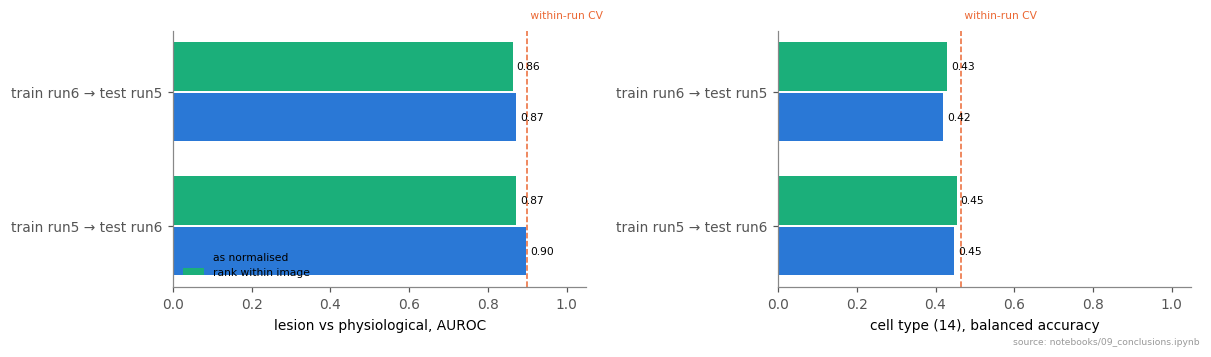

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (d, val, ref, lab) in zip(axs, ((transfer, "AUROC", within, "lesion vs physiological, AUROC"),
                                        (ct_transfer, "balanced_acc", 0.464, "cell type (14), balanced accuracy"))):
    piv = d.pivot(index="direction", columns="features", values=val)
    y = np.arange(len(piv))
    for k, c in enumerate(piv.columns):
        ax.barh(y + (k - 0.5) * 0.38, piv[c], height=0.36, color=plotting.CATEGORICAL[[0, 2][k]], label=c)
        for i, v in enumerate(piv[c]):
            ax.text(v + 0.01, y[i] + (k - 0.5) * 0.38, f"{v:.2f}", va="center", fontsize=7)
    ax.axvline(ref, color=plotting.CATEGORICAL[1], lw=1, ls="--")
    ax.text(ref, len(piv) - 0.45, " within-run CV", color=plotting.CATEGORICAL[1], fontsize=7)
    ax.set_yticks(y, piv.index); ax.set_xlim(0, 1.05); ax.set_xlabel(lab)
axs[0].legend(fontsize=7, loc="lower left")
fig.tight_layout()
plotting.save_fig(fig, "transfer_across_runs", OUT, SRC)

**Finding: the image models transfer across imaging runs.** A lesion model trained only on run5 animals maps lesions
in run6 at AUROC 0.90 (median per animal 0.91), and run6 → run5 at 0.87 — the same as within-run cross-validation
(0.90). Cell type transfers too (balanced accuracy 0.42–0.45 vs 0.46 within run; chance 0.07). Ranking features
within each image does not help (0.86–0.87 lesion), so the simple per-image normalisation of notebook 02 is enough.
The run signature that lets images identify their run perfectly sits in features the lesion and cell-type models
do not depend on. Caveat: two runs only, from the same lab and the same week; run6 has 6 animals.

## B. One figure

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/09_conclusions/conclusions_figure.png')

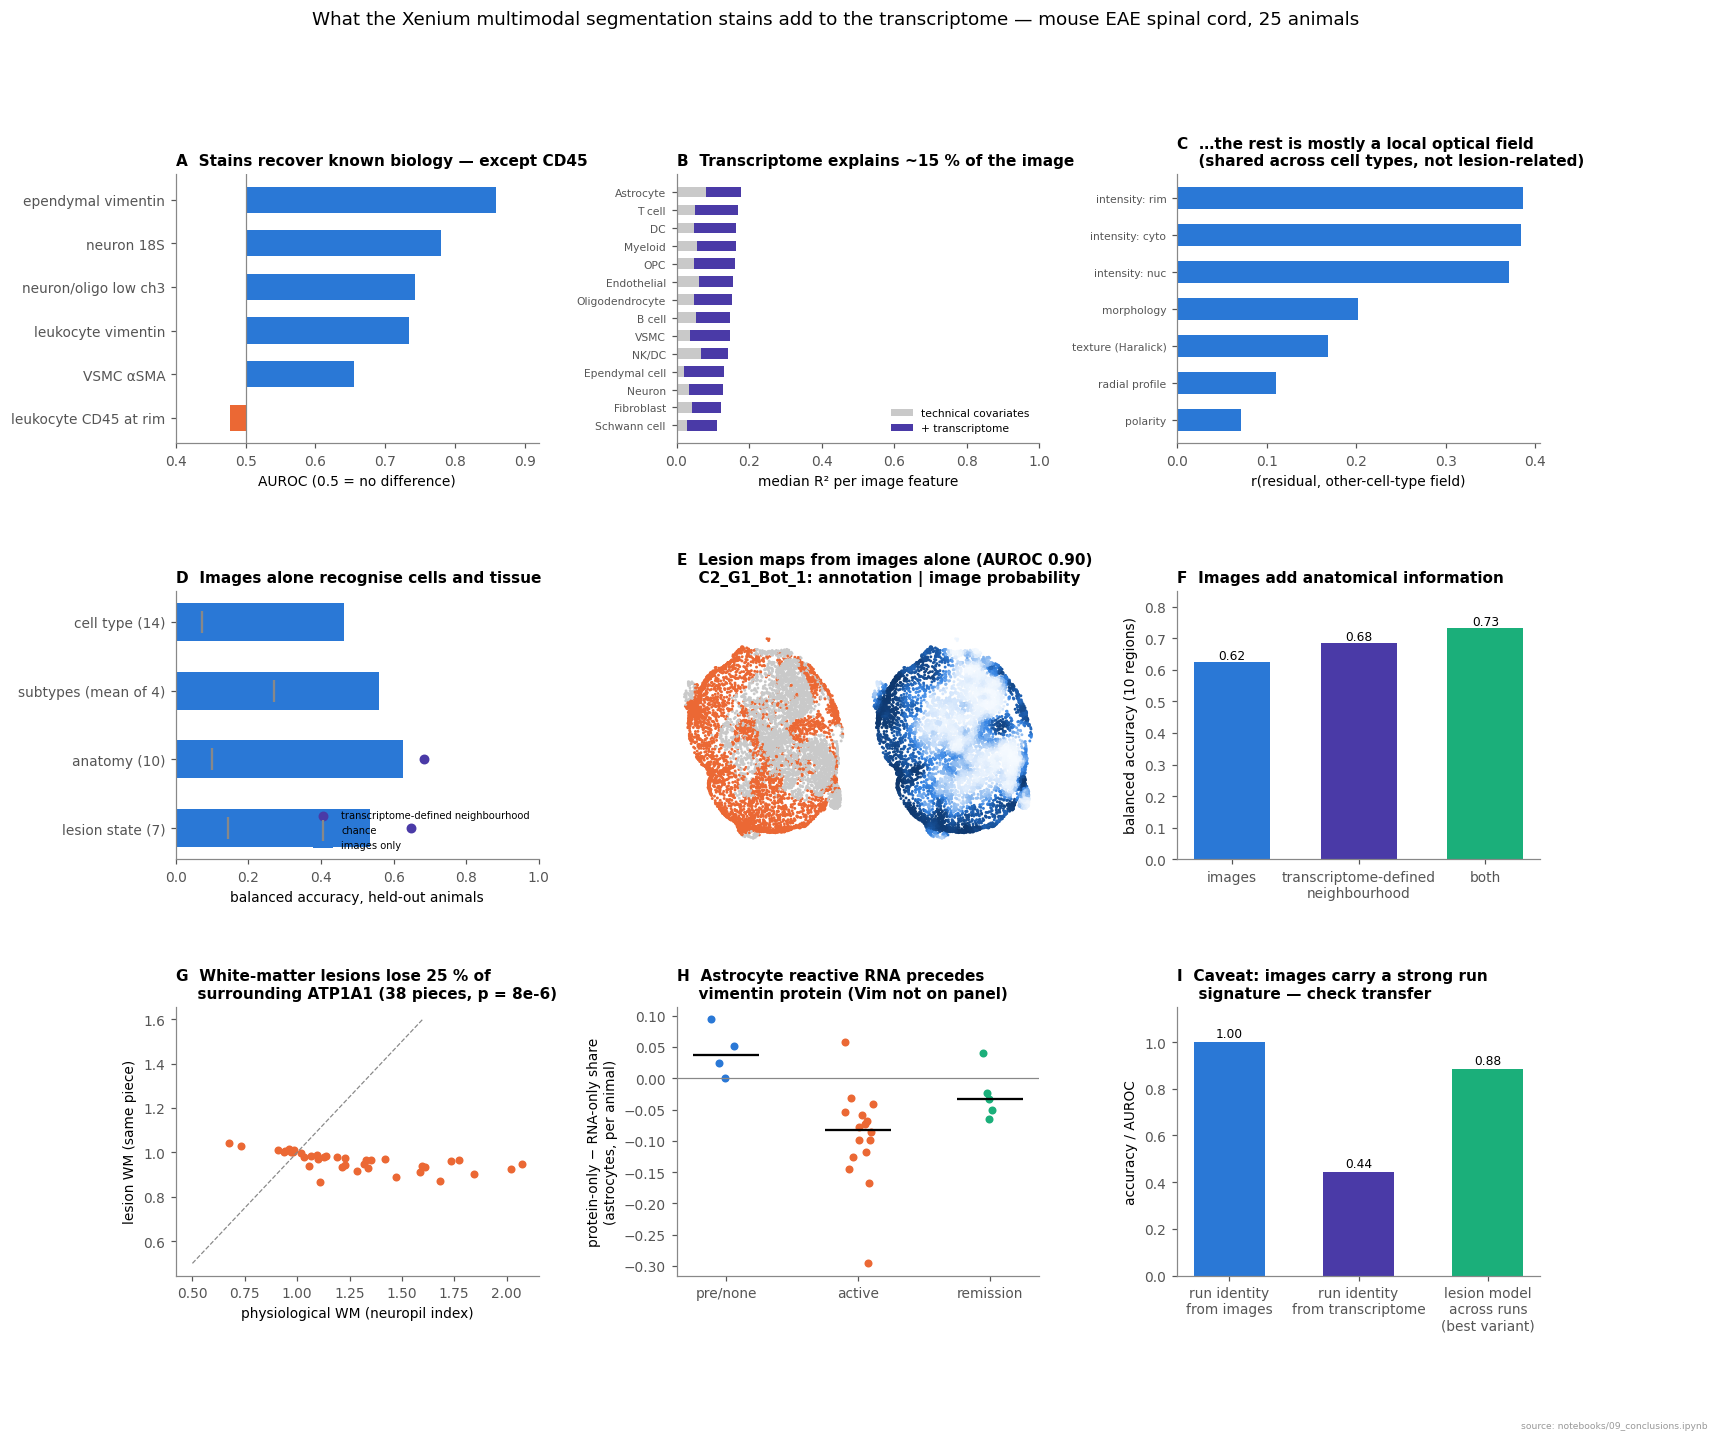

In [5]:
exp = pd.read_csv(RES / "03_sanity_atlas/expectation_tests.csv").query("stratum == 'all'")
r2 = pd.read_csv(RES / "04_orthogonality/r2_image_from_transcriptome.csv")
r2t = r2.groupby("cell_type")[["cov", "full"]].median().sort_values("full")
fs = pd.read_csv(RES / "05_field_and_animal/field_share.csv")
pred_task = pd.DataFrame({
    "task": ["cell type (14)", "subtypes (mean of 4)", "anatomy (10)", "lesion state (7)"],
    "images": [0.464, np.mean([0.640, 0.598, 0.533, 0.468]), 0.625, 0.535],
    "chance": [1 / 14, np.mean([1 / 3, 1 / 4, 1 / 4, 1 / 4]), 0.10, 1 / 7],
    "transcriptome-defined neighbourhood": [np.nan, np.nan, 0.683, 0.648]})
amp = pd.read_csv(RES / "08_image_only_prediction/anatomy_lesion_prediction.csv")
pp = pd.read_csv(RES / "06_targeted_readouts/neuropil_index_within_piece.csv")
quad = pd.read_csv(RES / "06_targeted_readouts/astro_quadrants_per_animal.csv")
tex = pd.read_csv(RES / "05_field_and_animal/r18s_texture_within_section.csv", index_col=0)
meta = pd.read_csv(RES / "08_image_only_prediction/animal_metadata_prediction.csv")
lm = pd.read_parquet(ROOT / "data" / "pred08" / "lesionmap_images.parquet").p

fig = plt.figure(figsize=(16, 13))
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.38)

# A — known biology
ax = fig.add_subplot(gs[0, 0])
lab = {"E1 leukocyte CD45 rim": "leukocyte CD45 at rim", "E2 VSMC αSMA": "VSMC αSMA", "E3 leukocyte vimentin vs neuron/oligo": "leukocyte vimentin",
       "E4 neuron/oligo low ch3": "neuron/oligo low ch3", "E5 ependymal vimentin": "ependymal vimentin", "E6 neuron 18S": "neuron 18S"}
e = exp.assign(label=exp.test.map(lab)).set_index("label").auroc.sort_values()
ax.barh(e.index, e.values - 0.5, left=0.5, color=[plotting.CATEGORICAL[1] if v < 0.55 else plotting.CATEGORICAL[0] for v in e.values], height=0.6)
ax.axvline(0.5, color="#888888", lw=0.8); ax.set_xlim(0.4, 0.92)
ax.set_xlabel("AUROC (0.5 = no difference)")
ax.set_title("A  Stains recover known biology — except CD45", loc="left", fontsize=10, fontweight="bold")

# B — how much the transcriptome explains
ax = fig.add_subplot(gs[0, 1])
y = np.arange(len(r2t))
ax.barh(y, r2t["cov"].clip(lower=0), color="#c9c9c9", height=0.6, label="technical covariates")
ax.barh(y, (r2t["full"] - r2t["cov"].clip(lower=0)).clip(lower=0), left=r2t["cov"].clip(lower=0), color=plotting.CATEGORICAL[6],
        height=0.6, label="+ transcriptome")
ax.set_yticks(y, r2t.index, fontsize=7); ax.set_xlim(0, 1)
ax.set_xlabel("median R² per image feature"); ax.legend(fontsize=7, loc="lower right")
ax.set_title("B  Transcriptome explains ~15 % of the image", loc="left", fontsize=10, fontweight="bold")

# C — what the unexplained part is
ax = fig.add_subplot(gs[0, 2])
fam = fs.groupby("family").r_field.median().sort_values()
ax.barh(fam.index, fam.values, color=plotting.CATEGORICAL[0], height=0.6)
ax.set_xlabel("r(residual, other-cell-type field)"); ax.tick_params(axis="y", labelsize=7)
ax.set_title("C  …the rest is mostly a local optical field\n    (shared across cell types, not lesion-related)", loc="left", fontsize=10, fontweight="bold")

# D — image-only prediction
ax = fig.add_subplot(gs[1, 0])
y = np.arange(len(pred_task))
ax.barh(y, pred_task.images, color=plotting.CATEGORICAL[0], height=0.55, label="images only")
ax.scatter(pred_task["transcriptome-defined neighbourhood"], y, color=plotting.CATEGORICAL[6], zorder=3, s=30,
           label="transcriptome-defined neighbourhood")
ax.scatter(pred_task.chance, y, color="#888888", marker="|", s=200, zorder=3, label="chance")
ax.set_yticks(y, pred_task.task); ax.set_xlim(0, 1); ax.invert_yaxis()
ax.set_xlabel("balanced accuracy, held-out animals"); ax.legend(fontsize=6.5, loc="lower right")
ax.set_title("D  Images alone recognise cells and tissue", loc="left", fontsize=10, fontweight="bold")

# E — lesion map (one piece)
piece = les.loc[lm.index].groupby("meta_sample_id", observed=True).y.mean()
PIECE = piece[(piece > 0.35) & (piece < 0.65)].index[0]
d = les.loc[lm.index]
d = d[d.meta_sample_id == PIECE]
xy = d[["x_centroid", "y_centroid"]].values
_, nn = cKDTree(xy).query(xy, k=16)
ps = lm[d.index].values[nn].mean(1)
sub = fig.add_subplot(gs[1, 1]); sub.axis("off")
sub.set_title(f"E  Lesion maps from images alone (AUROC 0.90)\n    {PIECE}: annotation | image probability",
              loc="left", fontsize=10, fontweight="bold")
a1 = sub.inset_axes([0.0, 0.0, 0.48, 0.9]); a2 = sub.inset_axes([0.52, 0.0, 0.48, 0.9])
a1.scatter(d.x_centroid, -d.y_centroid, s=0.8, c=np.where(d.y, plotting.CATEGORICAL[1], "#c9c9c9"), rasterized=True)
a2.scatter(d.x_centroid, -d.y_centroid, s=0.8, c=ps, cmap=plotting.SEQ, vmin=0, vmax=1, rasterized=True)
for a in (a1, a2):
    a.set_aspect("equal"); a.axis("off")

# F — images add anatomy
ax = fig.add_subplot(gs[1, 2])
g = amp[amp.task == "anatomical region"].set_index("inputs")["balanced acc."]
g.index = ["images", "transcriptome-defined\nneighbourhood", "both"]
ax.bar(g.index, g.values, color=[plotting.CATEGORICAL[k] for k in (0, 6, 2)], width=0.6)
for i, v in enumerate(g.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_ylim(0, 0.85); ax.set_ylabel("balanced accuracy (10 regions)")
ax.set_title("F  Images add anatomical information", loc="left", fontsize=10, fontweight="bold")

# G — neuropil loss
ax = fig.add_subplot(gs[2, 0])
w = pp[pp.region_class == "WM"]
ax.scatter(w.phys, w.lesion, s=18, color=plotting.CATEGORICAL[1])
ax.plot([0.5, 1.6], [0.5, 1.6], color="#888888", lw=0.8, ls="--")
ax.set(xlabel="physiological WM (neuropil index)", ylabel="lesion WM (same piece)")
ax.set_title("G  White-matter lesions lose 25 % of\n    surrounding ATP1A1 (38 pieces, p = 8e-6)", loc="left", fontsize=10, fontweight="bold")

# H — astrocyte RNA precedes vimentin
ax = fig.add_subplot(gs[2, 1])
order = ["pre/none", "active", "remission"]
vals = [quad.loc[quad.phase == ph, "protein_only_minus_rna_only"].values for ph in order]
for k, v in enumerate(vals):
    ax.scatter(np.full(len(v), k) + rng.uniform(-0.12, 0.12, len(v)), v, s=18, color=plotting.CATEGORICAL[k])
    ax.hlines(np.median(v), k - 0.25, k + 0.25, color="black", lw=1.5)
ax.axhline(0, color="#888888", lw=0.8)
ax.set_xticks(range(3), order); ax.set_ylabel("protein-only − RNA-only share\n(astrocytes, per animal)")
ax.set_title("H  Astrocyte reactive RNA precedes\n    vimentin protein (Vim not on panel)", loc="left", fontsize=10, fontweight="bold")

# I — batch
ax = fig.add_subplot(gs[2, 2])
rb = meta[meta.task.str.startswith("run5 vs run6")].set_index("input").value.reindex(["images", "transcriptome"])
best = transfer.groupby("features").AUROC.mean()
ax.bar(["run identity\nfrom images", "run identity\nfrom transcriptome"], rb.values, color=[plotting.CATEGORICAL[0], plotting.CATEGORICAL[6]], width=0.55)
ax.bar(["lesion model\nacross runs\n(best variant)"], [best.max()], color=plotting.CATEGORICAL[2], width=0.55)
for i, v in enumerate(list(rb.values) + [best.max()]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("accuracy / AUROC")
ax.set_title("I  Caveat: images carry a strong run\n    signature — check transfer", loc="left", fontsize=10, fontweight="bold")

fig.suptitle("What the Xenium multimodal segmentation stains add to the transcriptome — mouse EAE spinal cord, 25 animals",
             fontsize=12, y=0.995)
plotting.save_fig(fig, "conclusions_figure", OUT, SRC)

## C. Conclusions

**1. The stains are a real, independent measurement — of genes the panel does not contain.** *Vim*, *Acta2* and
*Atp1a1* are not on the 5K panel, so for three of the four stain targets the image is the only per-cell readout. The
stains recover known biology in every animal (VSMC αSMA, ependymal/leukocyte vimentin, neuronal 18S; AUROC
0.66–0.86, also in boundary-segmented cells). **CD45 is not detectable** — in mouse spinal cord the boundary channel is
ATP1A1 (neuropil) only.

**2. Most of what the images contain is *not* in the transcriptome — but most of that is optics, not hidden biology.**
Covariates + transcriptome explain a median ~15 % of each image feature. The remainder is spatially structured, but
largely a local field shared by all cell types (staining/optical; r ≈ 0.38) that does not track lesions; the
cell-specific remainder barely shifts with lesion state (19/924 tests, ~0.1 SD).

**3. Images alone recognise cells and map tissue.** Without any transcript, held-out animals: cell type 46 % (14 types,
chance 7 %), microglia 72 %, reactive astrocytes 68 %, anatomy 63 % (10 regions), and **lesion maps at AUROC 0.90**
(transcriptome-defined neighbourhood 0.92). For anatomy the images **add** to the transcriptome (0.68 → 0.73). For lesion
identity and clinical score they are redundant with it (score ρ 0.62 vs 0.79).

**4. Biology only the images show.**
- **Neuropil loss:** white-matter lesion tissue has 25 % less ATP1A1 around each cell than healthy white matter of the
  same piece (p = 8e-6) — tissue damage the cell's own transcriptome cannot carry.
- **Timing of astrocyte reactivity:** reactive transcription (*C3*, *Gfap*, *Serpina3n*…) precedes vimentin protein —
  "RNA-only" astrocytes peak in active disease (20 % vs 3.5 % in CFA).
- **Ribosomal RNA:** 18S rises in activated cells in lesions beyond their RNA content (Schwann +0.8, endothelium +0.4
  SD); the oligodendrocyte drop is RNA loss.
- **Perivascular T cells** orient their 18S-rich cytoplasm towards the vessel (cos 0.13–0.20; absent in neurons and
  oligodendrocytes — not blur).
- **Candidate severity marker:** smoother 18S texture in sicker animals, in six cell types, within sections and after
  a crowding adjustment (ρ 0.41–0.81) — needs replication.

**5. Caveats that shape how to use them.** Images identify the imaging run perfectly (transcriptome cannot), so raw
feature values should be compared within run — yet the lesion and cell-type models transfer between runs at
within-run accuracy (lesion AUROC 0.87–0.90, section A / panel I). 18S drew ~95 % of masks (18S distribution features
partly by construction); αSMA and vimentin share a channel; lesion niches are transcriptome-defined; 25 animals and
only two CFA pieces.

### How to use the segmentation stains
| use them for | don't use them for |
|---|---|
| vimentin / αSMA / ATP1A1 protein — targets missing from the panel | CD45 / immune membrane (undetectable in mouse cord) |
| tissue context: neuropil loss, anatomy, lesion maps from images | replacing the transcriptome for lesion identity or severity |
| protein-vs-RNA timing (e.g. astrocyte reactivity) | cell polarity from DAPI or αSMA/Vim (optical bleed) |
| 18S per cell as a ribosome / activation readout (adjusted for transcript density) | pooling raw image features across runs |
| QC: segmentation method, spill-over-prone neighbourhoods | 18S distribution features as biology in 18S-segmented cells |

### Next
1. Replicate on runs 1–3 (work drive): 18S texture marker, WM neuropil loss, astrocyte RNA → protein lag, T-cell
   polarity, and cross-run transfer of the image models (section A shows what to expect).
2. Separate vimentin from αSMA (VSMC-adjacent subset) and validate CD45 reactivity with 10x.
3. Feed neuropil-loss index and per-cell 18S into the RRMAP2 lesion/niche analyses as image-derived covariates.